## Análisis de datos II - Clase 4
---

### Detección de anomalías con Isolation Forest

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [189]:
# El archivo no trae encabezados,los definimos según wine.names
columnas = [
    'class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash',
    'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue',
    'od280_od315', 'proline'
]

df = pd.read_csv('../datasets/wine.data', header=None, names=columnas)
df.head()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


#### Vamos a analizar un mini dataset con estas dos variables

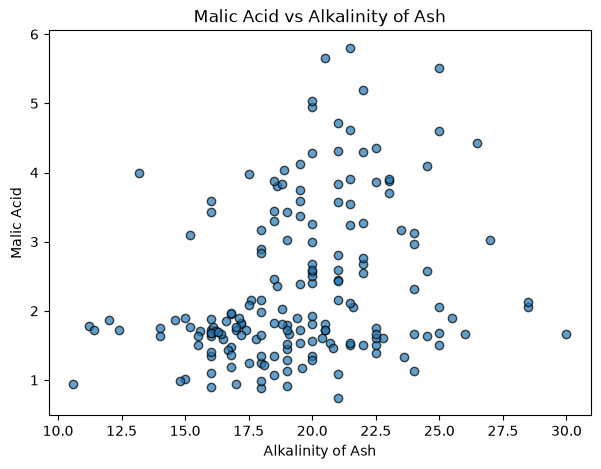

In [190]:
# Scatterplot: malic_acid (eje Y) vs alcalinity_of_ash (eje X)
plt.figure(figsize=(7, 5))
plt.scatter(df['alcalinity_of_ash'], df['malic_acid'], alpha=0.7, edgecolor='k')
plt.xlabel('Alkalinity of Ash')
plt.ylabel('Malic Acid')
plt.title('Malic Acid vs Alkalinity of Ash')
plt.show()

In [191]:

# Usar solo 2 variables para simplificar el ejemplo
features = ['malic_acid', 'alcalinity_of_ash']
X = df[features]

# Estandarizamos (no es prerrequisito para IS pero es buena práctica y para reusar el dataset)
X_escalado = StandardScaler().fit_transform(X)



In [192]:
# Contamination parameter: proporción de anomalías esperadas en el dataset
# Se selecciona con conocimiento del dominio.
if_model = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
# Ajustamos el modelo y predecimos anomalías
# Si predice -1 = anómalo, si predice 1 = normal
df['isof_pred'] = if_model.fit_predict(X_escalado)  

# Creamos una nueva col para guardar los scores
# La decisión_function devuelve un score de anormalidad: más negativo, más anómalo
df['isof_score'] = if_model.decision_function(X_escalado) 

# Filtro e imprimo algunos de los -1
print(f"Anomalías detectadas: {(df['isof_pred'] == -1).sum()} de {len(df)}")
df.sort_values('isof_score').head(10)[['alcalinity_of_ash', 'malic_acid', 'isof_pred','isof_score']]

Anomalías detectadas: 9 de 178


,alcalinity_of_ash,malic_acid,isof_pred,isof_score
59,10.6,0.94,-1,-0.085304
137,25.0,5.51,-1,-0.072696
73,30.0,1.67,-1,-0.067339
123,21.5,5.80,-1,-0.057262
39,13.2,3.99,-1,-0.056315
122,26.5,4.43,-1,-0.033763
173,20.5,5.65,-1,-0.033143
157,27.0,3.03,-1,-0.007698
127,28.5,2.13,-1,-0.006962
121,28.5,2.05,1,0.001229


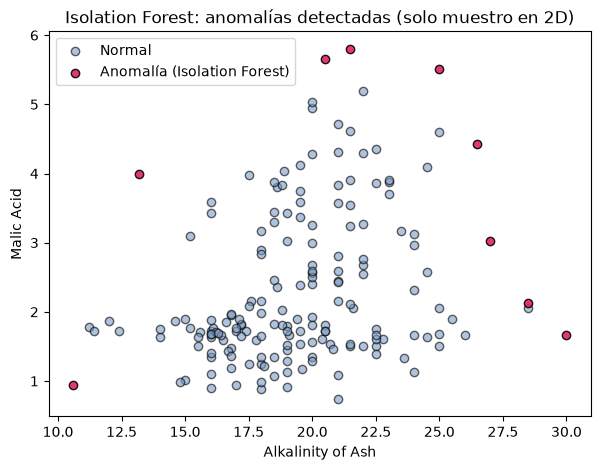

In [193]:
# Visualizamos las anomalías sobre el mismo scatterplot de la slide
plt.figure(figsize=(7, 5))
normales = df[df['isof_pred'] == 1]
anomalias = df[df['isof_pred'] == -1]

plt.scatter(normales['alcalinity_of_ash'], normales['malic_acid'],
            alpha=0.6, edgecolor='k', label='Normal', color='#7A9CC6')
plt.scatter(anomalias['alcalinity_of_ash'], anomalias['malic_acid'],
            alpha=0.9, edgecolor='k', label='Anomalía (Isolation Forest)',
            color='#E0245E')

plt.xlabel('Alkalinity of Ash')
plt.ylabel('Malic Acid')
plt.title('Isolation Forest: anomalías detectadas (solo muestro en 2D)')
plt.legend()
plt.show()

#### Análisis del dataset completo

In [194]:
#Otra opción: usar todas las variables numéricas (excluimos 'class', que es la etiqueta)
features_completo = [c for c in df.columns if c != 'class']
X_completo = df[features_completo].copy()

In [195]:
X_completo.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline',
       'isof_pred', 'isof_score'],
      dtype='object')

In [196]:
# Estandarizamos (no es prerrequisito para IS pero es buena práctica y para reusar el dataset)
X_escalado = StandardScaler().fit_transform(X_completo)

Ejecuto IF con todo el dataset completo

In [199]:
# Contamination parameter: proporción de anomalías esperadas en el dataset
# Se selecciona con conocimiento del dominio.
if_model = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
# Ajustamos el modelo y predecimos anomalías
# Si predice -1 = anómalo, si predice 1 = normal
df['isof_pred'] = if_model.fit_predict(X_completo)  

# Creamos una nueva col para guardar los scores
# La decisión_function devuelve un score de anormalidad: más negativo, más anómalo
df['isof_score'] = if_model.decision_function(X_completo) 

# Filtro e imprimo los -1
print(f"Anomalías detectadas: {(df['isof_pred'] == -1).sum()}")
df.sort_values('isof_score').head(10)[['alcalinity_of_ash', 'flavanoids', 'color_intensity', 'malic_acid', 'isof_pred','isof_score']]

Anomalías detectadas: 9


,alcalinity_of_ash,flavanoids,color_intensity,malic_acid,isof_pred,isof_score
59,10.6,0.57,1.95,0.94,-1,-0.091748
73,30.0,2.89,3.35,1.67,-1,-0.056707
121,28.5,5.08,6.00,2.05,-1,-0.034674
39,13.2,3.04,5.10,3.99,-1,-0.026527
123,21.5,2.65,2.60,5.80,-1,-0.026393
137,25.0,0.60,5.00,5.51,-1,-0.019435
157,27.0,0.58,7.50,3.03,-1,-0.011235
173,20.5,0.61,7.70,5.65,-1,-0.010305
158,25.0,1.31,13.00,1.68,-1,-0.006289
127,28.5,2.24,3.00,2.13,1,0.001110


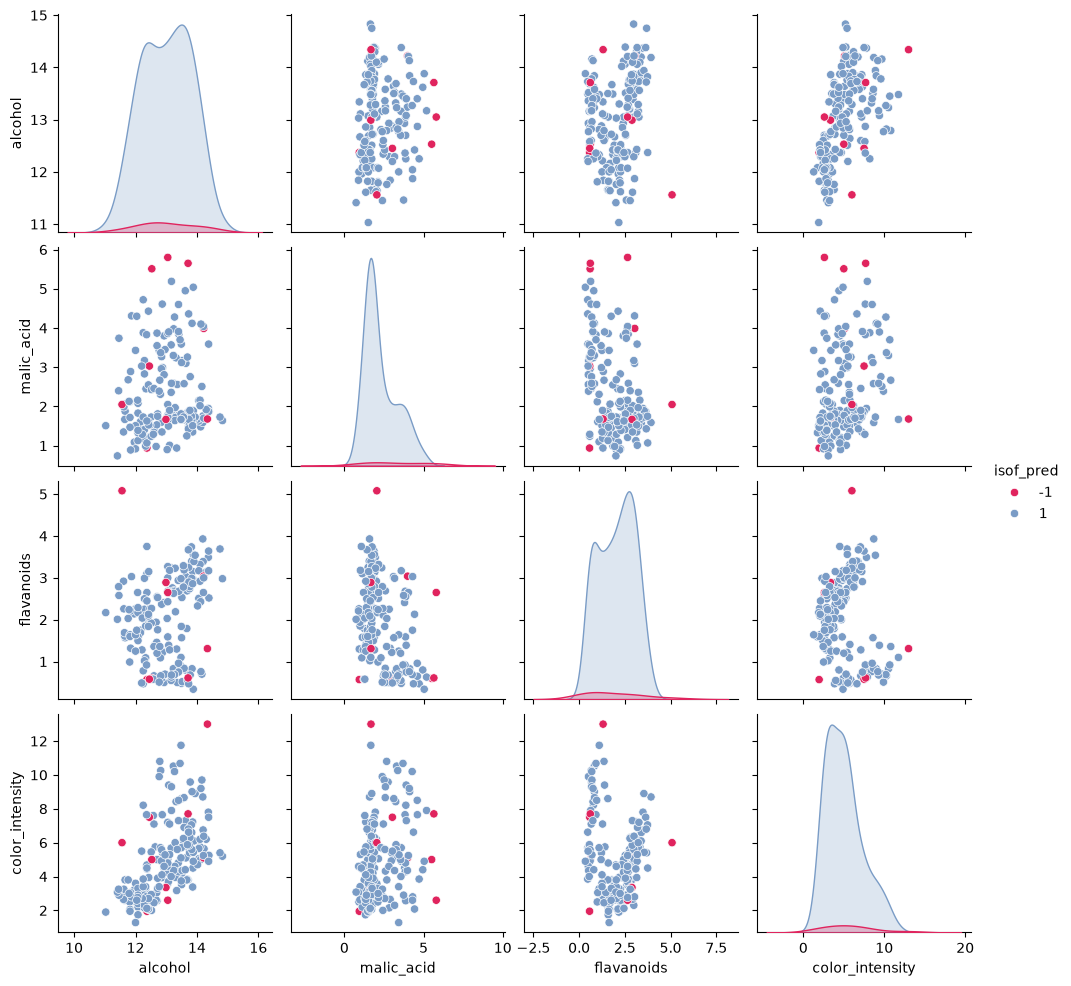

In [198]:
df_cols = df[['alcohol', 'malic_acid', 'flavanoids', 'color_intensity']]

palette = ['#E0245E', '#7A9CC6']
sns.pairplot(df, vars=df_cols.columns, hue='isof_pred', palette=palette)